In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from functools import cache

In [5]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from waymo_agent.models.ppo_model import RideShareActorCritic
from waymo_agent.graph_env.ENV import RideShareEnv
from waymo_agent.models.ppo_model import *

In [6]:
from waymo_agent.models.ppo_model import *
from waymo_agent.models.evaluate import *
from waymo_agent.models.train_utils import *

In [7]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

In [8]:
def get_obs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides


def get_obs_tuple_from_obs(obs: ObservationDict):
    veh = obs["vehicles"]
    req = obs["pending_requests"]
    rides = obs["active_rides"]
    return veh, req, rides

# Run Sim

In [ ]:
env_cfg = EnvConfig(
    max_episode_steps=60 * 1,
    vehicle_per_node=0.10,
    lambda_per_node=0.05,
    max_pending_requests=100,
    max_new_requests_per_step=20,
)
plt_cfg = PlotConfig()
env_model = RideShareEnv(env_cfg, plt_cfg)

Assigned lambda values to nodes. Total lambda: 39.1000 (target: 39.1000)


In [10]:
GAMMA = get_gamma_from_half_life(env_cfg.max_episode_steps // 2)
round(GAMMA, 5)

0.97716

In [11]:
def discounted_rewards(rewards: np.ndarray, gamma: float = 0.997) -> np.ndarray:
    """
    Discount rewards using discount factor gamma.
    """
    disc_schedule = exp_decay_half_life(len(rewards), gamma=gamma)
    return rewards * disc_schedule


def get_act_dict(agents: tuple[PricingAgent, DispatchAgent, RepositionAgent], obs: ObservationDict) -> ActionDict:
    price_agent, dispatch_agent, reposition_agent = agents
    prices = price_agent.price(obs)
    dispatch_actions = dispatch_agent.dispatch(obs)
    reposition_actions = reposition_agent.reposition(obs)

    action_agent: ActionDict = {
        "prices": prices,
        "dispatch": dispatch_actions,
        "reposition": reposition_actions,
    }
    return action_agent

In [12]:
@torch.no_grad()
def run_model_simulation(
    env_curr: RideShareEnv,
    model: RideShareActorCritic,
    num_iter: int = 1,
    gamma: float = GAMMA,
    deterministic: bool = False,
):
    """
    Returns:
      REWARDS: list[episode][t] discounted reward_t
      OBS:     list[episode][t] obs dict (numpy)
      ACT:     list[episode][t] action dict (numpy)
    """
    model.eval()

    REWARDS: list[np.ndarray] = []
    OBS: list[list[dict[str, np.ndarray]]] = []
    ACT: list[list[dict[str, np.ndarray]]] = []
    TERMINATED: list[bool] = []
    TRUNCATED: list[bool] = []

    for i in tqdm(range(num_iter), desc="model rollout"):
        # tqdm.write(f"Starting episode {i+1}/{num_iter}...")
        obs_np, _info = env_curr.reset()
        terminated = False
        truncated = False
        done = False

        rews_raw: list[float] = []
        obs_list: list[dict[str, np.ndarray]] = []
        act_list: list[dict[str, np.ndarray]] = []

        while not done:
            # tqdm.write(f"Step {env_curr.current_step}/{env_curr.config.max_episode_steps}")
            obs_list.append(obs_np)

            obs_t = obs_pd_to_torch(obs_np)

            act_t = model.act(obs_t, deterministic=deterministic)
            act_np = action_torch_to_numpy(act_t)
            env_curr._validate_action(act_np)
            act_list.append(act_np)

            obs_np, reward, terminated, truncated, _info = env_curr.step(act_np)  # type: ignore[arg-type]
            # print(f"Reward: {reward}")
            rews_raw.append(float(reward))
            done = bool(terminated) or bool(truncated)

        rews = discounted_rewards(np.array(rews_raw, dtype=np.float32), gamma=gamma)
        REWARDS.append(rews)
        OBS.append(obs_list)
        ACT.append(act_list)
        TERMINATED.append(terminated)
        TRUNCATED.append(truncated)

    return REWARDS, OBS, ACT, TERMINATED, TRUNCATED

In [29]:
model = RideShareActorCritic(env_model)
cfg_ppo = PPOTrainConfig(total_steps=120, gamma=GAMMA, log_every_updates=1)

In [14]:
REWARDS, OBS, ACT, TERMINATED, TRUNCATED = run_model_simulation(env_model, model, num_iter=1)

model rollout:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
TERMINATED, TRUNCATED

([False], [True])

In [16]:
env_model._rewards

{'penalty_multiple_dispatch_assignment': 4.8999999999999995,
 'penalty_assign_to_unavailable_vehicle': -8.2,
 'distance_penalty_xy_normed': 0.0,
 'penalty_rejected': np.float64(-0.0),
 'penalty_expire': np.float64(-0.0),
 'ride_reward_total': np.float64(-13.867806446706538)}

In [17]:
# import importlib
# import waymo_agent.data_classes.enriched_df_base

# _ = importlib.reload(waymo_agent.data_classes.enriched_df_base)

## NN Actor-Critic

In [ ]:
model = RideShareActorCritic(env_model)
cfg_ppo = PPOTrainConfig(total_steps=120, gamma=GAMMA, log_every_updates=1)

In [40]:
pprint(cfg_ppo)

PPOTrainConfig(total_steps=120,
               gamma=0.9771599684342459,
               gae_lambda=0.95,
               lr=0.0003,
               clip_eps=0.2,
               vf_coef=0.5,
               ent_coef=0.01,
               max_grad_norm=0.5,
               update_epochs=4,
               minibatch_size=256,
               deterministic_eval=True,
               log_every_updates=1,
               eval_episodes=2,
               eval_every_updates=5,
               patience=20,
               min_delta=0.001,
               save_best=True)


In [41]:
pprint(env_cfg)

EnvConfig(map_name='manhattan-sparse-782-nodes-enriched.graphml',
          map_dir=PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps'),
          vehicle_per_node=0.1,
          max_vehicles=50,
          time_step_delta=datetime.timedelta(seconds=60),
          max_episode_steps=60,
          day_per_week=7,
          hours_per_day=24,
          lambda_per_node=0.05,
          lambda_variation_coef=2.0,
          max_new_requests_per_step=20,
          max_pending_requests=100,
          max_wait_time_minutes=15,
          max_price=inf,
          invalid_id=-1,
          acceptance_margin_weight=-2.0,
          acceptance_supply_demand_weight=3.0,
          battery_consumption_per_km=0.01,
          charge_rate_per_minute=0.12,
          min_battery_for_assignment=0.2,
          chargable_node_ratio=0.01,
          max_chargers_per_node=1,
          penalty_rejected=-0.01,
          penalty_expire=-0.5,
          penalty_overflow=0,
          reward_frac_ride_completion=15.

In [42]:
obs, _ = env_model.reset()

In [43]:
veh, req, rides = get_obs_tuple(env_model)

In [44]:
dtt([veh, req, rides], how="head")

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 0 
 0 
 -0.573 
 -0.759 
 0.968 
 0 
 -1 
 
 
 1 
 1 
 -0.490 
 -0.457 
 0.790 
 0 
 -1 
 
 
 2 
 2 
 -0.262 
 -0.356 
 0.860 
 0 
 -1 
 
 
 3 
 3 
 0.135 
 -0.122 
 0.634 
 0 
 -1 
 
 
 4 
 4 
 -0.285 
 -0.720 
 0.907 
 0 
 -1 
 
 
 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 
 
 
 
 0 
 207507 
 2025-01-03 08:43:51.453565 
 16295 
 -4.478 
 2.414 
 12.128 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 486819535 
 -0.382 
 -0.673 
 3786728678 
 0.713 
 0.737 
 [486819535, 4561384853, 42427316, 42427324, 42427327, 42430041, 1918039897, 42445511, 42437612, 1773084402, 42440729, 42448701, 42436586, 42445378, 42449932, 42449685, 11337295608, 42444051, 42434087, 42438891, 42449956, 42436707, 42449963, 42448379, 42432856, 8133385388, 42449971, 4288677093, 6177439759, 42449985, 42447235, 42436486, 42436489, 42443027, 42429340, 42443054, 42443068, 3786728678] 
 486819535 
 4561384853 
 0.0 
 12128.127 
 
 
 1 
 207499 
 2025-01-03 08:43:51.453565 
 16933 
 -1.998 
 2.443 
 0.701 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 42448326 
 0.277 
 0.073 
 371188320 
 0.368 
 0.096 
 [42448326, 42448329, 42424672, 42427965, 42427968, 42427970, 371188320] 
 42448326 
 42448329 
 0.0 
 701.127 
 
 
 2 
 207515 
 2025-01-03 08:43:51.453565 
 34459 
 -0.666 
 1.791 
 2.679 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 9611529611 
 -0.492 
 -0.466 
 205025778 
 -0.307 
 -0.723 
 [9611529611, 4142105822, 4629486879, 4142105813, 42440838, 3788379733, 4143859873, 42440829, 42428433, 5706569898, 42427316, 42440804, 5161246307, 541467364, 1773066054, 588455742, 588455743, 42437749, 3884569931, 587988061, 205025778] 
 9611529611 
 4142105822 
 0.0 
 2678.838 
 
 
 3 
 207481 
 2025-01-03 08:43:51.453565 
 6989 
 -0.876 
 2.482 
 10.787 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 42427327 
 -0.282 
 -0.535 
 42444457 
 0.661 
 0.773 
 [42427327, 42430041, 1918039897, 42445511, 42448693, 3786901738, 3786901743, 42458333, 42446941, 42446942, 11337295604, 42444049, 42434085, 42438889, 42446991, 42436705, 42446998, 42432847, 42447009, 42447020, 42447060, 42447069, 42436484, 42447105, 42429334, 42447166, 42447182, 42444457] 
 42427327 
 42430041 
 0.0 
 10787.191 
 
 
 4 
 207492 
 2025-01-03 08:43:51.453565 
 47976 
 -0.567 
 2.090 
 9.714 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 42440829 
 -0.391 
 -0.526 
 7076060066 
 0.494 
 0.594 
 [42440829, 42428436, 42428438, 1919595915, 42428447, 42428473, 4597668041, 561042190, 561042193, 561042192, 100522479, 9140654137, 596775840, 596775867, 596775870, 596775900, 596775919, 596775935, 596775946, 6177439752, 596776032, 596775979, 596776057, 596776089, 596776164, 596776260, 7076060066] 
 42440829 
 42428436 
 0.0 
 9713.640 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 0 
 -1 
 0 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 1 
 -1 
 1 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 2 
 -1 
 2 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 3 
 -1 
 3 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 4 
 -1 
 4 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [45]:
model, logs = ppo_model.train_ppo(
    env_model, model, train_cfg=cfg_ppo, save_path=MODEL_WEIGHT_DIR / "ppo_model_final.pt"
)

PPO steps:   0%|          | 0/120 [00:00<?, ?step/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

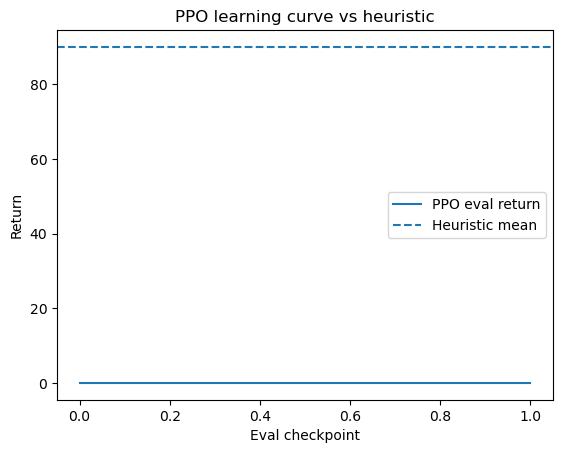

In [46]:
plot_learning_curve_vs_baseline(logs, heur_mean=env_cfg.max_episode_steps * 1.5)

In [52]:
model = RideShareActorCritic(env_model)
cfg_ppo = PPOTrainConfig(total_steps=120, gamma=GAMMA, log_every_updates=1)

In [53]:
_ = model.forward(obs_pd_to_torch(obs))

X:tensor([-0.4339, -0.9010,  0.7551,  ...,  0.0000,  0.0000,  0.0000],
       device='mps:0')


X:tensor([-0.4339, -0.9010,  0.7551,  ...,  0.0000,  0.0000,  0.0000],
       device='mps:0')


H:tensor([  0.0000, 221.3191,   0.0000,  65.3764,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000, 139.5224,
          0.0000, 225.6833,   0.0000, 238.3851,   0.0000,  42.1201,   0.0000,
        265.0928,  36.1974,  13.5607, 172.2459,   0.0000,   0.0000, 262.1730,
          0.0000,   0.0000,   0.0000,   0.0000,  62.3101, 141.7259,   0.0000,
          0.0000,   0.0000,  36.7768,  38.0391,   0.0000,   0.0000,  75.4636,
        218.2792,  68.9338,   0.0000,   0.0000,   5.9303, 111.1291,  37.2419,
         46.5438, 238.3352,   0.0000, 102.1102,   0.0000,  66.8547,   0.0000,
          0.0000,   0.0000, 107.2112, 252.0874,   0.0000,  42.9705,   0.0000,
          0.0000, 114.3659,   0.0000,  77.7110, 165.9347,   0.0000,  83.7697,
        145.6905,  71.5836

In [54]:
out = model.act(obs_pd_to_torch(obs), deterministic=False)

X:tensor([-0.4339, -0.9010,  0.7551,  ...,  0.0000,  0.0000,  0.0000],
       device='mps:0')


X:tensor([-0.4339, -0.9010,  0.7551,  ...,  0.0000,  0.0000,  0.0000],
       device='mps:0')


H:tensor([  0.0000, 221.3191,   0.0000,  65.3764,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000, 139.5224,
          0.0000, 225.6833,   0.0000, 238.3851,   0.0000,  42.1201,   0.0000,
        265.0928,  36.1974,  13.5607, 172.2459,   0.0000,   0.0000, 262.1730,
          0.0000,   0.0000,   0.0000,   0.0000,  62.3101, 141.7259,   0.0000,
          0.0000,   0.0000,  36.7768,  38.0391,   0.0000,   0.0000,  75.4636,
        218.2792,  68.9338,   0.0000,   0.0000,   5.9303, 111.1291,  37.2419,
         46.5438, 238.3352,   0.0000, 102.1102,   0.0000,  66.8547,   0.0000,
          0.0000,   0.0000, 107.2112, 252.0874,   0.0000,  42.9705,   0.0000,
          0.0000, 114.3659,   0.0000,  77.7110, 165.9347,   0.0000,  83.7697,
        145.6905,  71.5836

In [55]:
out

{'prices': tensor([3.4045e-05, 3.7210e+04, 1.3107e-04, 1.6489e-05, 3.1222e-05, 4.0474e-05,
         4.6140e+04, 3.6307e-05, 4.7440e-05, 3.1965e-05, 7.8906e-05, 2.1786e-03,
         2.0473e+04, 2.5810e+03, 5.1490e-05, 3.3091e-05, 4.0751e+04, 6.0721e-05,
         2.8001e+01, 3.3031e-05, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06,
         1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06,
         1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06,
         1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06,
         1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06,
         1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06,
         1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06,
         1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06,
         1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06,
         1.0000e-0

In [ ]:
env_model.step()